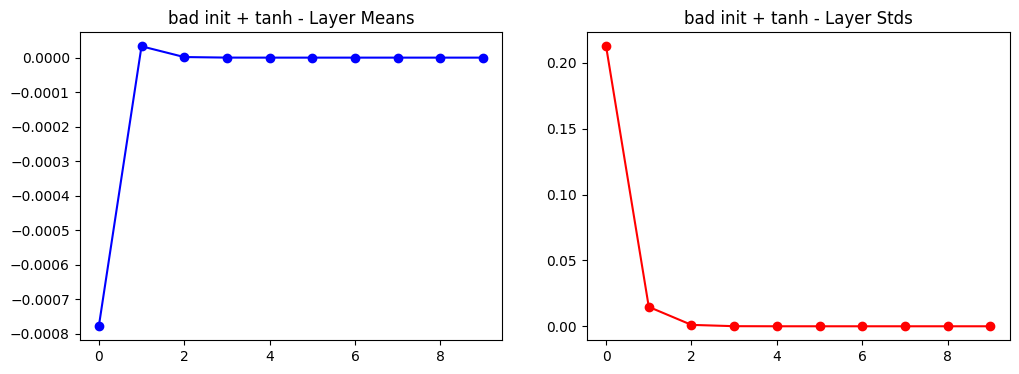

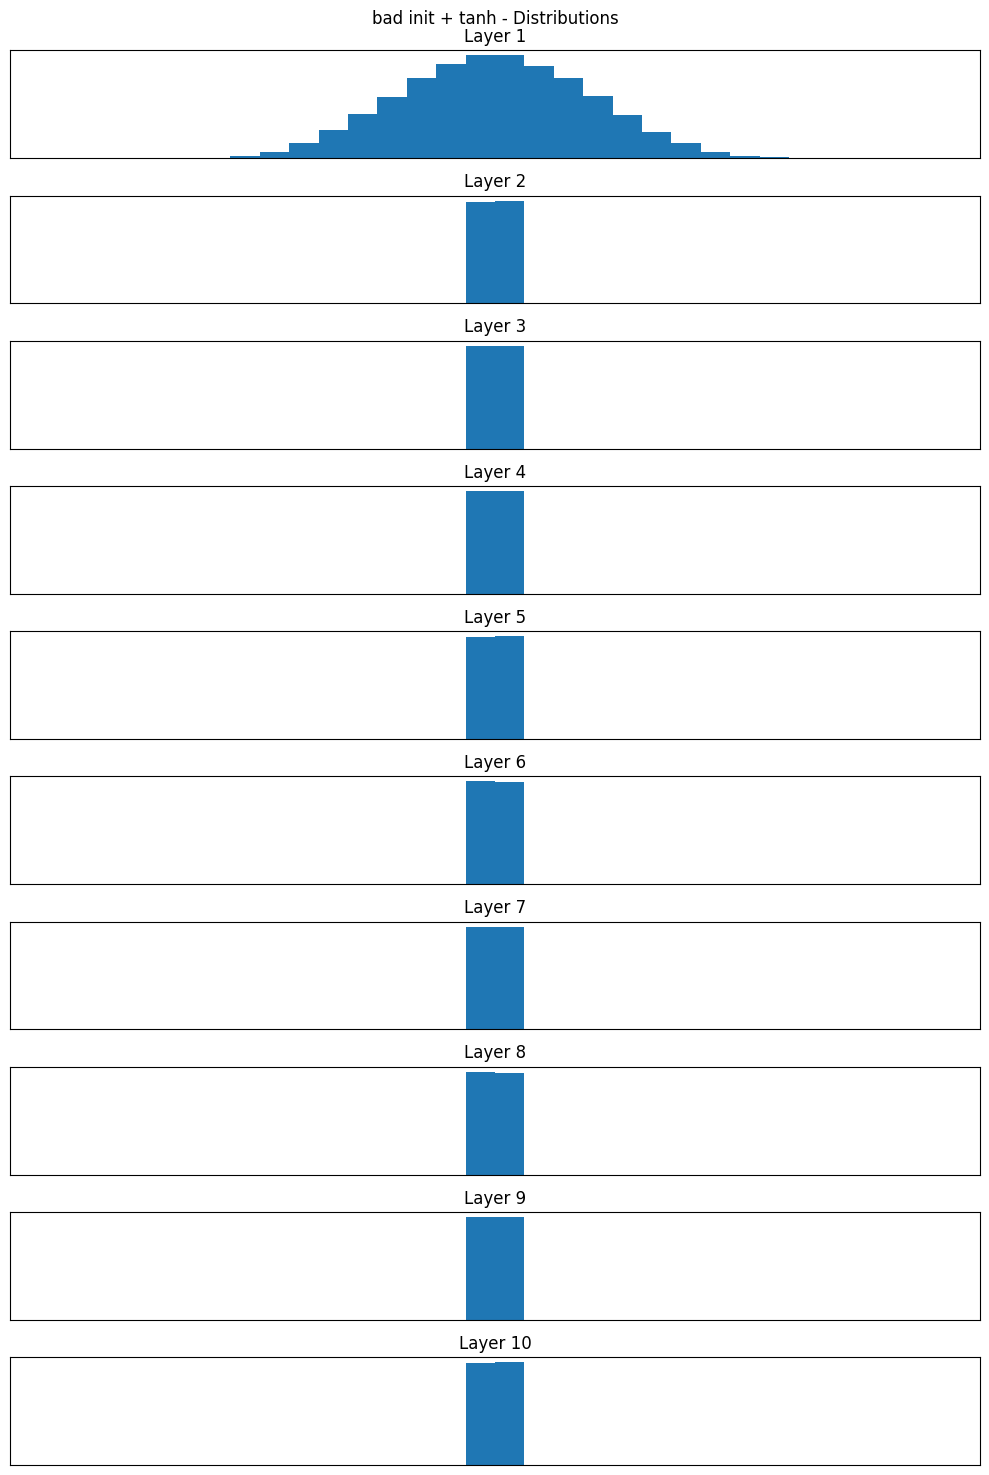

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
D = 500  # input size
N = 1000 # number of samples
hidden_layer_sizes = [50] * 10  # 10 layers, each with 50 neurons
nonlinearities = ['tanh']  # activation function

# Activation functions
act_funcs = {
    'relu': lambda x: np.maximum(0, x),
    'tanh': lambda x: np.tanh(x)
}

# Weight initialization methods
init_methods = {
    'bad': lambda fan_in, fan_out: np.random.randn(fan_in, fan_out) * 0.01,  # Bad initialization with small values
}

# Experiment function
def run_and_plot(activation, init_type):
    np.random.seed(0)
    X = np.random.randn(N, D)  # input data
    Hs = {}
    nonlin = act_funcs[activation]
    init_fn = init_methods[init_type]

    # Iterate through layers and apply initialization + activation
    for i in range(len(hidden_layer_sizes)):
        X = X if i == 0 else Hs[i-1]
        fan_in = X.shape[1]
        fan_out = hidden_layer_sizes[i]
        W = init_fn(fan_in, fan_out)  # weight initialization
        H = X @ W  # linear transformation
        H = nonlin(H)  # apply activation function
        Hs[i] = H  # store the result for later analysis

    # Calculate mean and standard deviation for each layer's activations
    layer_means = [np.mean(H) for H in Hs.values()]
    layer_stds = [np.std(H) for H in Hs.values()]

    # Plot mean and standard deviation across layers
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(Hs.keys(), layer_means, 'ob-')
    plt.title(f'{init_type} init + {activation} - Layer Means')

    plt.subplot(1, 2, 2)
    plt.plot(Hs.keys(), layer_stds, 'or-')
    plt.title(f'{init_type} init + {activation} - Layer Stds')
    plt.show()

    # Plot histograms of activations at each layer
    plt.figure(figsize=(10, 15))
    for i, H in Hs.items():
        plt.subplot(len(Hs), 1, i + 1)
        plt.hist(H.ravel(), bins=30, range=(-1, 1))
        plt.title(f'Layer {i+1}')
        plt.xticks([])
        plt.yticks([])
    plt.suptitle(f'{init_type} init + {activation} - Distributions')
    plt.tight_layout()
    plt.show()

# -------------------
# Experiments
# -------------------
run_and_plot('tanh', 'bad')  # ❌ Bad initialization with tanh activation function
